  # Deep Q-Network (DQN)

 * Full Name: Yashar Zafari

 * Student Number: 404210253

In [1]:
import os, random, cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from collections import deque, namedtuple
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import gymnasium as gym
from IPython.display import HTML
from base64 import b64encode


/home/ama/miniconda3/envs/rlgpu/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ========================  Configuration  ========================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


/home/ama/miniconda3/envs/rlgpu/lib/python3.7/site-packages/torch/cuda/__init__.py:52: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at  /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


In [3]:
def show_video(video_path, width=480):
    """Display an existing .mp4 file in the notebook."""
    with open(video_path, "rb") as f:
        video_data = f.read()
    encoded = b64encode(video_data).decode("utf-8")
    html = f'''
        <video width="{width}" controls>
            <source src="data:video/mp4;base64,{encoded}" type="video/mp4">
        </video>
    '''
    return HTML(html)


def save_agent_video(env, agent, filename="agent_demo.mp4", max_steps=1000):
    """
    Record one episode (greedy) and save as video.
    Tries several codecs; falls back to saving frames as .npy if all fail.
    Returns the filename if successful, else None.
    """
    state, _ = env.reset()
    done = False
    frames = []
    while not done and len(frames) < max_steps:
        action = agent.select_action(state, training=False)  # GREEDY
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        frames.append(env.render())
        state = next_state

    if not frames:
        return None

    height, width, _ = frames[0].shape

    # Codec/container combinations to attempt
    codec_tries = [
        (cv2.VideoWriter_fourcc(*'avc1'), '.mp4'),
        (cv2.VideoWriter_fourcc(*'mp4v'), '.mp4'),
        (cv2.VideoWriter_fourcc(*'XVID'), '.avi'),
        (cv2.VideoWriter_fourcc(*'MJPG'), '.avi'),
    ]
    base, _ = os.path.splitext(filename)

    for fourcc, ext in codec_tries:
        trial_path = f"{base}{ext}"
        out = cv2.VideoWriter(trial_path, fourcc, 30, (width, height))
        if out.isOpened():
            for f in frames:
                out.write(cv2.cvtColor(f, cv2.COLOR_RGB2BGR))
            out.release()
            if os.path.exists(trial_path) and os.path.getsize(trial_path) > len(frames) * 500:
                print(f"Video saved: {trial_path}")
                return trial_path
            else:
                try:
                    os.remove(trial_path)
                except:
                    pass

    # Fallback: save raw frames as .npy
    npy_path = f"{base}_frames.npy"
    np.save(npy_path, np.array(frames))
    print(f"All codecs failed. Raw frames saved to {npy_path}")
    return None   # indicate video file not usable


def show_agent_episode(env, agent, max_steps=500, fps=30):
    """Play one episode directly in the notebook (no video file needed)."""
    import time
    from IPython.display import clear_output, display
    state, _ = env.reset()
    done = False
    fig, ax = plt.subplots()
    ax.axis('off')
    for _ in range(max_steps):
        action = agent.select_action(state, training=False)
        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        ax.imshow(env.render())
        clear_output(wait=True)
        display(fig)
        time.sleep(1 / fps)
        if done:
            break
    plt.close(fig)

In [4]:
# =================  Environment Check (LunarLander-v3)  =========
env = gym.make('LunarLander-v2', render_mode='rgb_array')
nA = env.action_space.n
nS = env.observation_space.shape[0]
print(f'Action space: {nA}, Observation space: {nS}')

class TestAgent:
    def __init__(self, nA):
        self.nA = nA
    def select_action(self, s, training=False):
        return random.randint(0, self.nA - 1)

# Create demo video if it doesn't exist
test_video_path = 'initial test/agent_test.mp4'
if not os.path.exists(test_video_path):
    os.makedirs(os.path.dirname(test_video_path), exist_ok=True)
    test_env = gym.make('LunarLander-v2', render_mode='rgb_array')
    save_agent_video(test_env, TestAgent(nA), filename=test_video_path)
    test_env.close()
show_video(test_video_path)


Action space: 4, Observation space: 8


In [5]:
# ======================  Data Structures  =======================
Transition = namedtuple('Transition', ['state', 'action', 'reward', 'next_state', 'done'])

class ReplayBuffer:
    def __init__(self, capacity=20000):
        self.buffer = deque(maxlen=capacity)

    def push(self, *args):
        self.buffer.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.buffer, batch_size)

    def __len__(self):
        return len(self.buffer)


In [6]:
# ======================  Neural Networks  =======================
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

    def forward(self, x):
        return self.network(x)

class DuelingQNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.features = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU()
        )
        self.value_stream = nn.Sequential(
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
        self.advantage_stream = nn.Sequential(
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

    def forward(self, x):
        feat = self.features(x)
        value = self.value_stream(feat)
        advantage = self.advantage_stream(feat)
        return value + advantage - advantage.mean(dim=1, keepdim=True)


In [7]:
# ==================  Base DQN Agent (refactored) ================
class BaseDQNAgent:
    def __init__(self, state_dim, action_dim, device,
                 q_network=None, target_network=None,
                 gamma=0.99, epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.9995,
                 batch_size=64, target_update_freq=2000, lr=0.0005):
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.batch_size = batch_size
        self.target_update_freq = target_update_freq
        self.action_dim = action_dim
        self.device = device

        self.q_network = q_network.to(device)
        self.target_network = target_network.to(device)
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval()

        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)
        self.memory = ReplayBuffer()
        self.steps = 0

    def select_action(self, state, training=True):
        state_t = torch.tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
        if training and random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)
        with torch.no_grad():
            return self.q_network(state_t).argmax(dim=1).item()

    def store_transition(self, state, action, reward, next_state, done):
        self.memory.push(state, action, reward, next_state, done)

    def _prepare_batch(self, batch):
        states = torch.tensor(np.array([t.state for t in batch]), dtype=torch.float32, device=self.device)
        actions = torch.tensor([[t.action] for t in batch], dtype=torch.long, device=self.device)
        rewards = torch.tensor([[t.reward] for t in batch], dtype=torch.float32, device=self.device)
        next_states = torch.tensor(np.array([t.next_state for t in batch]), dtype=torch.float32, device=self.device)
        dones = torch.tensor([[t.done] for t in batch], dtype=torch.float32, device=self.device)
        return states, actions, rewards, next_states, dones

    def update(self):
        if len(self.memory) < self.batch_size:
            return None
        batch = self.memory.sample(self.batch_size)
        states, actions, rewards, next_states, dones = self._prepare_batch(batch)

        current_q = self.q_network(states).gather(1, actions)

        with torch.no_grad():
            # Vanilla DQN: max over target network
            next_q = self.target_network(next_states).max(1, keepdim=True).values
            target_q = rewards + self.gamma * next_q * (1 - dones)

        loss = F.smooth_l1_loss(current_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.steps += 1
        if self.steps % self.target_update_freq == 0:
            self.target_network.load_state_dict(self.q_network.state_dict())

        self.epsilon = max(self.epsilon * self.epsilon_decay, self.epsilon_min)
        return loss.item()


In [8]:
# ======================  Double DQN Agent =======================
class DDQNAgent(BaseDQNAgent):
    def __init__(self, state_dim, action_dim, device,
                 q_network, target_network, **kwargs):
        super().__init__(state_dim, action_dim, device,
                         q_network=q_network, target_network=target_network, **kwargs)

    def update(self):
        if len(self.memory) < self.batch_size:
            return None
        batch = self.memory.sample(self.batch_size)
        states, actions, rewards, next_states, dones = self._prepare_batch(batch)

        current_q = self.q_network(states).gather(1, actions)

        with torch.no_grad():
            # Double DQN: online selects, target evaluates
            next_actions = self.q_network(next_states).argmax(1, keepdim=True)
            next_q = self.target_network(next_states).gather(1, next_actions)
            target_q = rewards + self.gamma * next_q * (1 - dones)

        loss = F.smooth_l1_loss(current_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.steps += 1
        if self.steps % self.target_update_freq == 0:
            self.target_network.load_state_dict(self.q_network.state_dict())

        self.epsilon = max(self.epsilon * self.epsilon_decay, self.epsilon_min)
        return loss.item()


In [9]:
# =====================  Dueling DQN Agent =======================
class DuelingDQNAgent(DDQNAgent):   # Inherits Double DQN update logic, just uses Dueling networks
    def __init__(self, state_dim, action_dim, device, **kwargs):
        q_net = DuelingQNetwork(state_dim, action_dim)
        target_net = DuelingQNetwork(state_dim, action_dim)
        super().__init__(state_dim, action_dim, device,
                         q_network=q_net, target_network=target_net, **kwargs)


In [10]:
# ========================  PER (SumTree) ========================
class SumTree:
    def __init__(self, capacity):
        self.capacity = capacity
        self.tree = np.zeros(2 * capacity - 1, dtype=np.float32)
        self.data = np.empty(capacity, dtype=object)
        self.write_idx = 0
        self.size = 0

    def add(self, priority, transition):
        idx = self.write_idx + self.capacity - 1
        self.data[self.write_idx] = transition
        self.update(idx, priority)
        self.write_idx = (self.write_idx + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def update(self, idx, priority):
        change = priority - self.tree[idx]
        self.tree[idx] = priority
        while idx != 0:
            idx = (idx - 1) // 2
            self.tree[idx] += change

    def sample(self, batch_size):
        """Return (batch, priorities, indices) – guaranteed no None transitions."""
        if self.size == 0:
            raise RuntimeError("SumTree is empty, cannot sample")

        batch = []
        indices = []
        priorities = []

        total_priority = self.tree[0]   # root of the tree array
        if total_priority == 0.0:
            raise RuntimeError("SumTree total priority is zero")

        segment = total_priority / batch_size

        for i in range(batch_size):
            low = segment * i
            high = segment * (i + 1)

            # Try up to 50 times to hit a valid leaf
            for _ in range(50):
                r = random.uniform(low, high)
                idx = self._find_leaf(0, r)
                data_idx = idx - self.capacity + 1
                if self.data[data_idx] is not None:
                    break
                # Expand range slightly if stuck
                low = max(0.0, low - 0.01 * total_priority)
                high = min(total_priority, high + 0.01 * total_priority)
            else:
                # Fallback: pick any valid leaf
                valid = [j for j, d in enumerate(self.data) if d is not None]
                data_idx = random.choice(valid)
                idx = data_idx + self.capacity - 1

            batch.append(self.data[data_idx])
            priorities.append(self.tree[idx])
            indices.append(idx)

        return batch, priorities, indices

    def _find_leaf(self, idx, value):
        while True:
            left = 2 * idx + 1
            right = left + 1
            if left >= len(self.tree):
                return idx
            if value <= self.tree[left]:
                idx = left
            else:
                value -= self.tree[left]
                idx = right

    def __len__(self):
        return self.size

class PrioritizedReplayBuffer:
    def __init__(self, capacity=20000, alpha=0.4, beta=0.4, beta_increment=4e-6, device='cpu'):
        self.tree = SumTree(capacity)
        self.alpha = alpha
        self.beta = beta
        self.beta_increment = beta_increment
        self.epsilon = 1e-5
        self.max_priority = 1.0                # will be updated automatically
        self.device = device

    def push(self, transition):
        self.tree.add(self.max_priority, transition)

    def sample(self, batch_size):
        """Return (states, actions, rewards, ...) tensors on the correct device."""
        if len(self.tree) < batch_size:
            raise RuntimeError("Not enough transitions in buffer to sample a batch")

        # Sample from SumTree; guaranteed no None transitions now
        batch, priorities, indices = self.tree.sample(batch_size)

        # Convert to numpy priority array
        priorities = np.array(priorities, dtype=np.float32)
        total_priority = self.tree.tree[0]   # root priority
        probs = priorities / total_priority

        weights = (self.tree.size * probs) ** (-self.beta)
        self.beta = min(1.0, self.beta + self.beta_increment)
        weights /= weights.max()   # stable normalization

        # Build tensors
        states = torch.tensor(np.array([t.state for t in batch]), dtype=torch.float32, device=self.device)
        actions = torch.tensor([[t.action] for t in batch], dtype=torch.long, device=self.device)
        rewards = torch.tensor([[t.reward] for t in batch], dtype=torch.float32, device=self.device)
        next_states = torch.tensor(np.array([t.next_state for t in batch]), dtype=torch.float32, device=self.device)
        dones = torch.tensor([[t.done] for t in batch], dtype=torch.float32, device=self.device)
        weights = torch.tensor(weights, dtype=torch.float32, device=self.device).unsqueeze(1)

        return states, actions, rewards, next_states, dones, weights, indices

    def update_priorities(self, indices, td_errors):
        for idx, error in zip(indices, td_errors):
            priority = (abs(error) + self.epsilon) ** self.alpha
            self.tree.update(idx, priority)
            self.max_priority = max(self.max_priority, priority)

    def __len__(self):
        return len(self.tree)


In [11]:
# ======================  PER DQN Agent ==========================
class PERDQNAgent:
    def __init__(self, state_dim, action_dim, device, gamma=0.99,
                 epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.9995,
                 batch_size=64, target_update_freq=2000, lr=0.0005):
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.batch_size = batch_size
        self.target_update_freq = target_update_freq
        self.action_dim = action_dim
        self.device = device

        self.q_network = QNetwork(state_dim, action_dim).to(device)
        self.target_network = QNetwork(state_dim, action_dim).to(device)
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval()

        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)
        self.memory = PrioritizedReplayBuffer(capacity=20000, alpha=0.4, beta=0.4,
                                              beta_increment=4e-6, device=device)
        self.steps = 0

    def select_action(self, state, training=True):
        state_t = torch.tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
        if training and random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)
        with torch.no_grad():
            return self.q_network(state_t).argmax(dim=1).item()

    def store_transition(self, state, action, reward, next_state, done):
        self.memory.push(Transition(state, action, reward, next_state, done))

    def update(self):
        if len(self.memory) < self.batch_size:
            return None

        states, actions, rewards, next_states, dones, weights, indices = self.memory.sample(self.batch_size)

        current_q = self.q_network(states).gather(1, actions)

        with torch.no_grad():
            # Double DQN target for PER
            next_actions = self.q_network(next_states).argmax(1, keepdim=True)
            next_q = self.target_network(next_states).gather(1, next_actions)
            target_q = rewards + self.gamma * next_q * (1 - dones)

        # *** FIX: Huber loss (recommended by PER paper) ***
        loss_per_element = F.smooth_l1_loss(current_q, target_q, reduction='none')
        loss = (weights * loss_per_element).mean()

        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.q_network.parameters(), 1.0)
        self.optimizer.step()

        # *** FIX: use squeeze(1) to avoid 0-d case ***
        td_errors = (current_q - target_q).detach().abs().squeeze(1).cpu().numpy()
        self.memory.update_priorities(indices, td_errors)

        self.steps += 1
        if self.steps % self.target_update_freq == 0:
            self.target_network.load_state_dict(self.q_network.state_dict())

        self.epsilon = max(self.epsilon * self.epsilon_decay, self.epsilon_min)
        return loss.item()


In [ ]:
# ==================  Combined (Half‑Rainbow) Agent ==============
class CombinedDQNAgent:
    def __init__(self, state_dim, action_dim, device, gamma=0.99,
                 epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.9995,
                 batch_size=64, target_update_freq=2000, lr=0.0005):
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.batch_size = batch_size
        self.target_update_freq = target_update_freq
        self.action_dim = action_dim
        self.device = device

        self.q_network = DuelingQNetwork(state_dim, action_dim).to(device)
        self.target_network = DuelingQNetwork(state_dim, action_dim).to(device)
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval()

        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)
        # ** FIX: beta_increment = 1e-4 **
        self.memory = PrioritizedReplayBuffer(capacity=20000, alpha=0.4, beta=0.4,
                                              beta_increment=4e-6, device=device)
        self.steps = 0

    def select_action(self, state, training=True):
        state_t = torch.tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
        if training and random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)
        with torch.no_grad():
            return self.q_network(state_t).argmax(dim=1).item()

    def store_transition(self, state, action, reward, next_state, done):
        self.memory.push(Transition(state, action, reward, next_state, done))

    def update(self):
        if len(self.memory) < self.batch_size:
            return None

        states, actions, rewards, next_states, dones, weights, indices = self.memory.sample(self.batch_size)

        current_q = self.q_network(states).gather(1, actions)

        with torch.no_grad():
            # Double DQN + Dueling
            next_actions = self.q_network(next_states).argmax(1, keepdim=True)
            next_q = self.target_network(next_states).gather(1, next_actions)
            target_q = rewards + self.gamma * next_q * (1 - dones)

        # *** Huber loss ***
        loss_per_element = F.smooth_l1_loss(current_q, target_q, reduction='none')
        loss = (weights * loss_per_element).mean()

        self.optimizer.zero_grad()
        loss.backward()

        # *** Gradient clipping (uncommented) ***
        nn.utils.clip_grad_norm_(self.q_network.parameters(), 1.0)
        self.optimizer.step()

        td_errors = (current_q - target_q).detach().abs().squeeze(1).cpu().numpy()
        self.memory.update_priorities(indices, td_errors)

        self.steps += 1
        if self.steps % self.target_update_freq == 0:
            self.target_network.load_state_dict(self.q_network.state_dict())

        self.epsilon = max(self.epsilon * self.epsilon_decay, self.epsilon_min)
        return loss.item()


In [13]:
def train_dqn(env, agent, num_episodes=500, max_steps=1000, base_seed=42):
    scores = []
    losses = []
    for episode in range(num_episodes):
        state, _ = env.reset(seed=base_seed + episode)
        score = 0
        ep_loss = 0.0
        n_updates = 0
        for step in range(max_steps):
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            agent.store_transition(state, action, reward, next_state, done)
            loss_val = agent.update()
            if loss_val is not None:
                ep_loss += loss_val
                n_updates += 1
            score += reward
            state = next_state
            if done:
                break
        scores.append(score)
        losses.append(ep_loss / n_updates if n_updates > 0 else 0.0)
    return scores, losses

def run_experiment_multi_seed(agent_name, agent_class, make_kwargs, seeds, num_episodes=500):
    """
    Train the same agent on multiple seeds, return all_scores (num_seeds × num_episodes)
    Also returns the state_dict of the first‑seed agent (for video demo).
    """
    all_scores = []
    agent_state = None          # will hold the trained weights (CPU) from the first seed
    print(f"\n{'='*60}")
    print(f"Training {agent_name} on {len(seeds)} seeds")
    print(f"{'='*60}")
    for i, seed in enumerate(seeds):
        print(f"\n--- Seed {seed} ({i+1}/{len(seeds)}) ---")
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed(seed)

        env = gym.make('LunarLander-v2')
        kwargs = make_kwargs(state_dim, action_dim, device)  # fresh networks
        agent = agent_class(**kwargs)
        scores, _ = train_dqn(env, agent, num_episodes=num_episodes, base_seed=seed)
        all_scores.append(scores)
        env.close()

        # Save the first‑seed agent’s weights (move to CPU so they survive the GPU cleanup)
        if i == 0:
            agent_state = {k: v.cpu() for k, v in agent.q_network.state_dict().items()}

        # Clean up GPU to prevent the CUDA error
        del agent
        if torch.cuda.is_available():
            torch.cuda.synchronize()
            torch.cuda.empty_cache()

    return np.array(all_scores), agent_state

In [14]:
def build_agent_with_weights(agent_name, state_dim, action_dim, device,
                             agent_configs, agent_weights):
    """Recreate an agent of the given type and load its saved state_dict."""
    if agent_name not in agent_configs or agent_name not in agent_weights:
        raise ValueError(f"Unknown agent {agent_name} or missing weights")
    agent_cls, make_kwargs = agent_configs[agent_name]
    kwargs = make_kwargs(state_dim, action_dim, device)   # fresh networks
    agent = agent_cls(**kwargs)
    agent.q_network.load_state_dict(agent_weights[agent_name])
    agent.target_network.load_state_dict(agent_weights[agent_name])
    return agent

In [15]:
# List of seeds for each agent
seeds = [42, 123, 456]   # 3 seeds; you can add more

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

def make_dqn_networks(state_dim, action_dim):
    return QNetwork(state_dim, action_dim), QNetwork(state_dim, action_dim)

def make_dueling_networks(state_dim, action_dim):
    return DuelingQNetwork(state_dim, action_dim), DuelingQNetwork(state_dim, action_dim)

# Update agent_configs:
agent_configs = {
    'DQN': (BaseDQNAgent, lambda sd, ad, dev: dict(
                state_dim=sd, action_dim=ad, device=dev,
                q_network=QNetwork(sd, ad),
                target_network=QNetwork(sd, ad))),
    'Double DQN': (DDQNAgent, lambda sd, ad, dev: dict(
                   state_dim=sd, action_dim=ad, device=dev,
                   q_network=QNetwork(sd, ad),
                   target_network=QNetwork(sd, ad))),
    'Dueling DQN': (DuelingDQNAgent, lambda sd, ad, dev: dict(
                     state_dim=sd, action_dim=ad, device=dev)),
    'PER DQN': (PERDQNAgent, lambda sd, ad, dev: dict(
                  state_dim=sd, action_dim=ad, device=dev)),
    'Combined': (CombinedDQNAgent, lambda sd, ad, dev: dict(
                   state_dim=sd, action_dim=ad, device=dev)),
}

results = {}
agent_weights = {}   # will hold state_dict for each agent (first seed only)

for name, (agent_cls, make_kwargs) in agent_configs.items():
    scores, agent_state = run_experiment_multi_seed(name, agent_cls, make_kwargs, seeds, num_episodes=500)
    results[name] = scores
    agent_weights[name] = agent_state   # save the trained weights (first seed)


Training DQN on 3 seeds

--- Seed 42 (1/3) ---

--- Seed 123 (2/3) ---

--- Seed 456 (3/3) ---

Training Double DQN on 3 seeds

--- Seed 42 (1/3) ---

--- Seed 123 (2/3) ---

--- Seed 456 (3/3) ---

Training Dueling DQN on 3 seeds

--- Seed 42 (1/3) ---

--- Seed 123 (2/3) ---

--- Seed 456 (3/3) ---

Training PER DQN on 3 seeds

--- Seed 42 (1/3) ---

--- Seed 123 (2/3) ---

--- Seed 456 (3/3) ---

Training Combined on 3 seeds

--- Seed 42 (1/3) ---

--- Seed 123 (2/3) ---

--- Seed 456 (3/3) ---


In [16]:
combined_agent = build_agent_with_weights('Combined', state_dim, action_dim, device,
                                          agent_configs, agent_weights)

In [17]:
for name, state in agent_weights.items():
    torch.save(state, f"weights_{name.replace(' ', '_')}.pth")

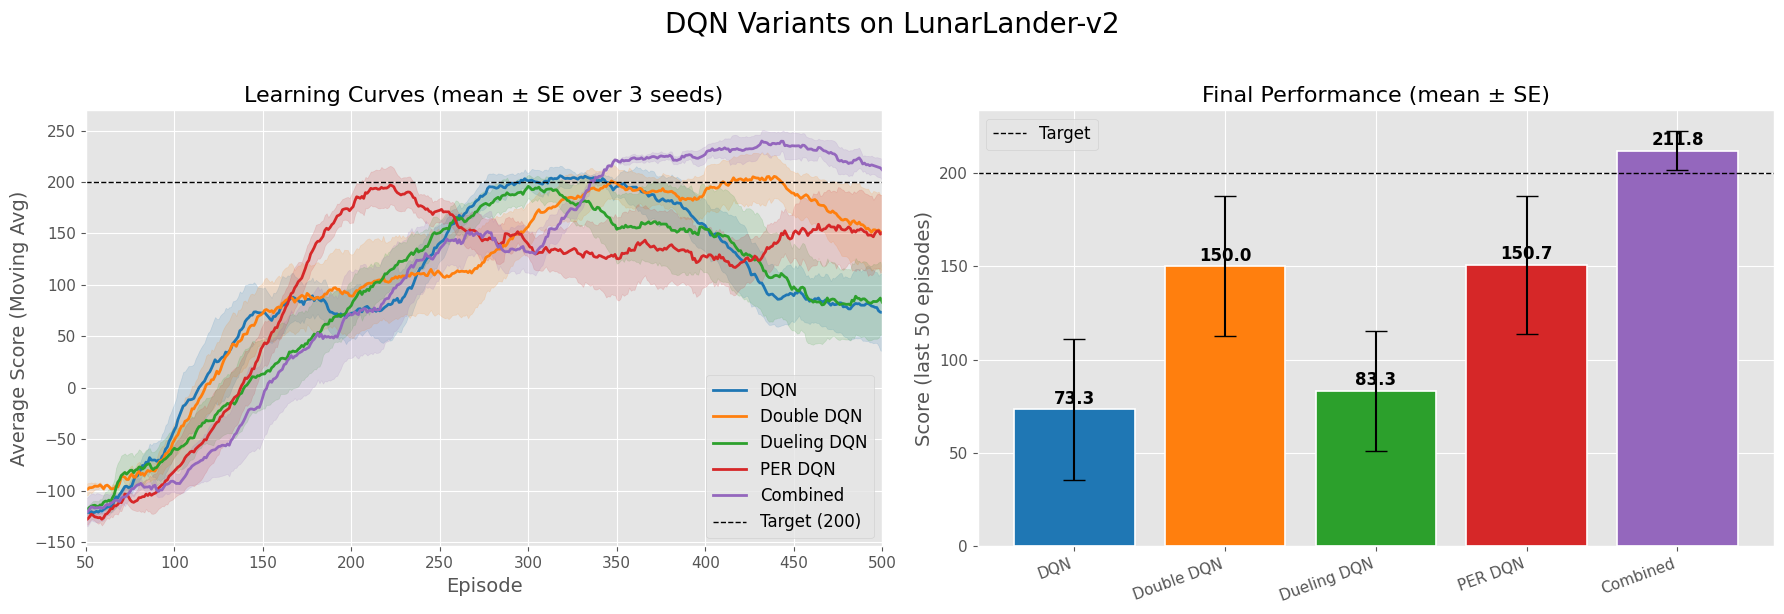


FINAL SUMMARY (over 3 seeds)
DQN            : 73.3 ± 37.5
Double DQN     : 150.0 ± 37.5
Dueling DQN    : 83.3 ± 32.1
PER DQN        : 150.7 ± 37.0
Combined       : 211.8 ± 10.5


In [18]:
# Style settings for a clean look
plt.style.use('ggplot')
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'legend.fontsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

window = 50  # moving average window

# Prepare data: moving average of each seed, then mean and std across seeds
def compute_mean_std(scores_array, window=50):
    """
    scores_array: shape (num_seeds, num_episodes)
    Returns: mean_curve (length num_episodes - window + 1), std_curve (same length)
    """
    num_seeds, num_ep = scores_array.shape
    ma_curves = []
    for s in range(num_seeds):
        ma = np.convolve(scores_array[s], np.ones(window)/window, mode='valid')
        ma_curves.append(ma)
    ma_curves = np.array(ma_curves)  # (num_seeds, num_ep-window+1)
    mean_curve = ma_curves.mean(axis=0)
    std_curve = ma_curves.std(axis=0)   # standard deviation across seeds
    # Standard error of the mean (more common in papers)
    stderr_curve = std_curve / np.sqrt(num_seeds)
    return mean_curve, stderr_curve, ma_curves

colors = {
    'DQN': '#1f77b4',
    'Double DQN': '#ff7f0e',
    'Dueling DQN': '#2ca02c',
    'PER DQN': '#d62728',
    'Combined': '#9467bd'
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# ---- Left plot: learning curves ----
x = np.arange(window, 500+1)
for name, scores_array in results.items():
    mean_curve, stderr_curve, _ = compute_mean_std(scores_array, window=window)
    ax1.plot(x, mean_curve, color=colors[name], linewidth=2, label=name)
    ax1.fill_between(x, mean_curve - stderr_curve, mean_curve + stderr_curve,
                     color=colors[name], alpha=0.15)
ax1.axhline(y=200, color='black', linestyle='--', linewidth=1, label='Target (200)')
ax1.set_xlabel('Episode')
ax1.set_ylabel('Average Score (Moving Avg)')
ax1.set_title('Learning Curves (mean ± SE over 3 seeds)')
ax1.legend(loc='lower right')
ax1.set_xlim(window, 500)
ax1.yaxis.set_major_locator(ticker.MultipleLocator(50))

# ---- Right plot: final performance bar chart ----
final_avg = []
final_stderr = []
names = list(results.keys())
for name in names:
    scores = results[name][:, -50:].mean(axis=1)  # average over last 50 episodes for each seed
    final_avg.append(scores.mean())
    final_stderr.append(scores.std() / np.sqrt(len(seeds)))

x_pos = np.arange(len(names))
bars = ax2.bar(x_pos, final_avg, yerr=final_stderr, capsize=8,
               color=[colors[n] for n in names], edgecolor='white', linewidth=1.2)
ax2.axhline(y=200, color='black', linestyle='--', linewidth=1, label='Target')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(names, rotation=20, ha='right')
ax2.set_ylabel('Score (last 50 episodes)')
ax2.set_title('Final Performance (mean ± SE)')
# Annotate bars
for bar, avg in zip(bars, final_avg):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             f'{avg:.1f}', ha='center', fontweight='bold')
ax2.legend()

plt.suptitle('DQN Variants on LunarLander-v2', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "="*60)
print("FINAL SUMMARY (over {} seeds)".format(len(seeds)))
print("="*60)
for name, avg, err in zip(names, final_avg, final_stderr):
    print(f"{name:<15}: {avg:.1f} ± {err:.1f}")
print("="*60)

In [19]:
# Final summary
print("\n" + "="*60)
print("FINAL SUMMARY (Last 50 Episodes)")
print("="*60)
final_avgs = {}
for name, scores in results.items():
    avg = np.mean(scores[:, -50:], axis=1).mean()
    final_avgs[name] = avg
    print(f"{name:<20}: {avg:.1f}")
print("="*60)

# Save and show video of the Combined agent (from first seed)
env_render = gym.make('LunarLander-v2', render_mode='rgb_array')
video_file = save_agent_video(env_render, combined_agent, 'halfrainbow_v3.mp4')

if video_file:
    env_render.close()
    print("Video saved:", video_file)
    show_video(video_file)
else:
    print("Video saving failed. Falling back to notebook player.")
    show_agent_episode(env_render, combined_agent)
    env_render.close()


FINAL SUMMARY (Last 50 Episodes)
DQN                 : 73.3
Double DQN          : 150.0
Dueling DQN         : 83.3
PER DQN             : 150.7
Combined            : 211.8


[ERROR:0@7888.586] global cap_ffmpeg_impl.hpp:3203 open Could not find encoder for codec_id=27, error: Encoder not found
[ERROR:0@7888.586] global cap_ffmpeg_impl.hpp:3281 open VIDEOIO/FFMPEG: Failed to initialize VideoWriter


Video saved: halfrainbow_v3.mp4
Video saved: halfrainbow_v3.mp4
